In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [10]:
df = pd.read_csv('Diwali Sales Data.csv', encoding = 'unicode_escape')

In [16]:
df.shape
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


In [18]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [19]:
df.drop(['Status','unnamed1'], axis = 1 , inplace = True)

In [22]:
df.isnull()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,False,False,False,False,False,False,False,False,False,False,False,False,False
11247,False,False,False,False,False,False,False,False,False,False,False,False,False
11248,False,False,False,False,False,False,False,False,False,False,False,False,False
11249,False,False,False,False,False,False,False,False,False,False,False,False,False


In [24]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [27]:
df.dropna(inplace = True)

In [31]:
df['Amount'] = df['Amount'].astype('int')

In [33]:
df['Amount'].dtype

dtype('int64')

In [35]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='str')

In [38]:
df.rename(columns = {'Marital_Status' : 'Shaadi'}, inplace = True)

In [42]:
df.describe()

,User_ID,Age,Shaadi,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


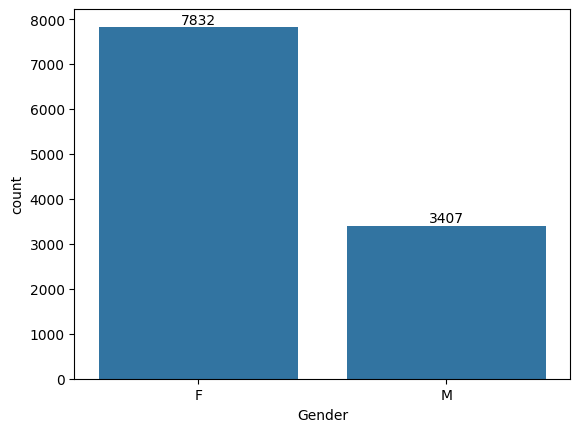

In [46]:
ax = sns.countplot(x = 'Gender', data = df)
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Gender', ylabel='Amount'>

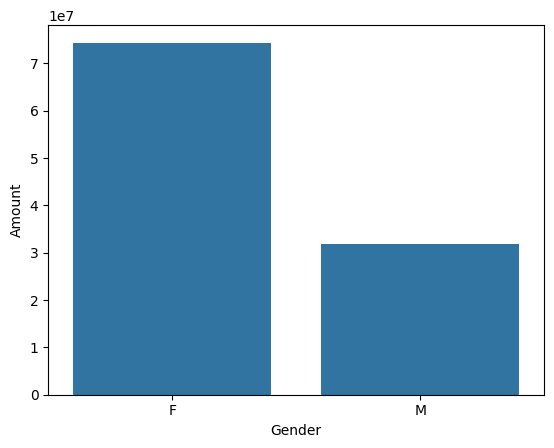

In [52]:
sales_gen = df.groupby(['Gender'], as_index = False)['Amount'].sum().sort_values(by = ['Amount'], ascending = False)

sns.barplot(x = 'Gender', y = 'Amount', data = sales_gen)


<Axes: xlabel='Age Group', ylabel='Amount'>

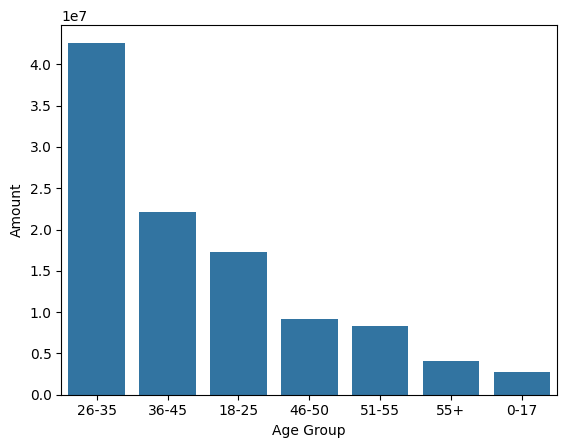

In [54]:
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by = ['Amount'], ascending = False)
sns.barplot(x='Age Group', y = 'Amount', data = sales_age)

<Axes: xlabel='State', ylabel='Orders'>

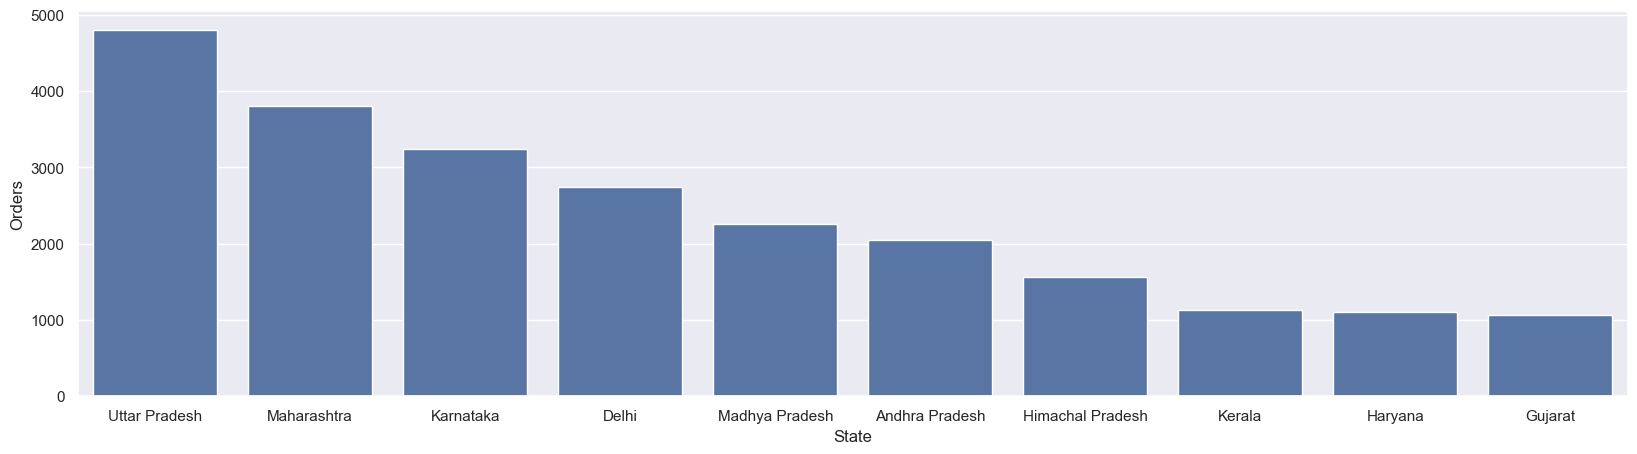

In [63]:
sales_state = df.groupby(['State'], as_index=False )['Orders'].sum().sort_values(by = ['Orders'], ascending = False).head(10)


sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(x = 'State', y = 'Orders', data = sales_state)

<Axes: xlabel='State', ylabel='Amount'>

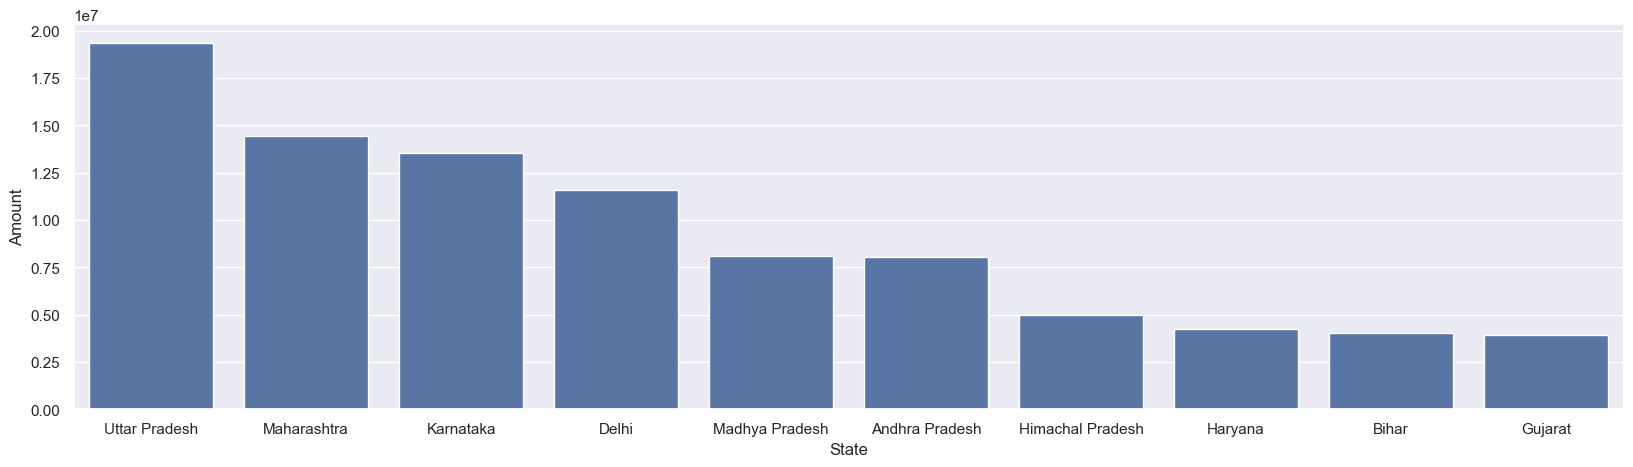

In [65]:
sales_state = df.groupby(['State'], as_index=False )['Amount'].sum().sort_values(by = ['Amount'], ascending = False).head(10)
sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(x = 'State', y = 'Amount', data = sales_state)


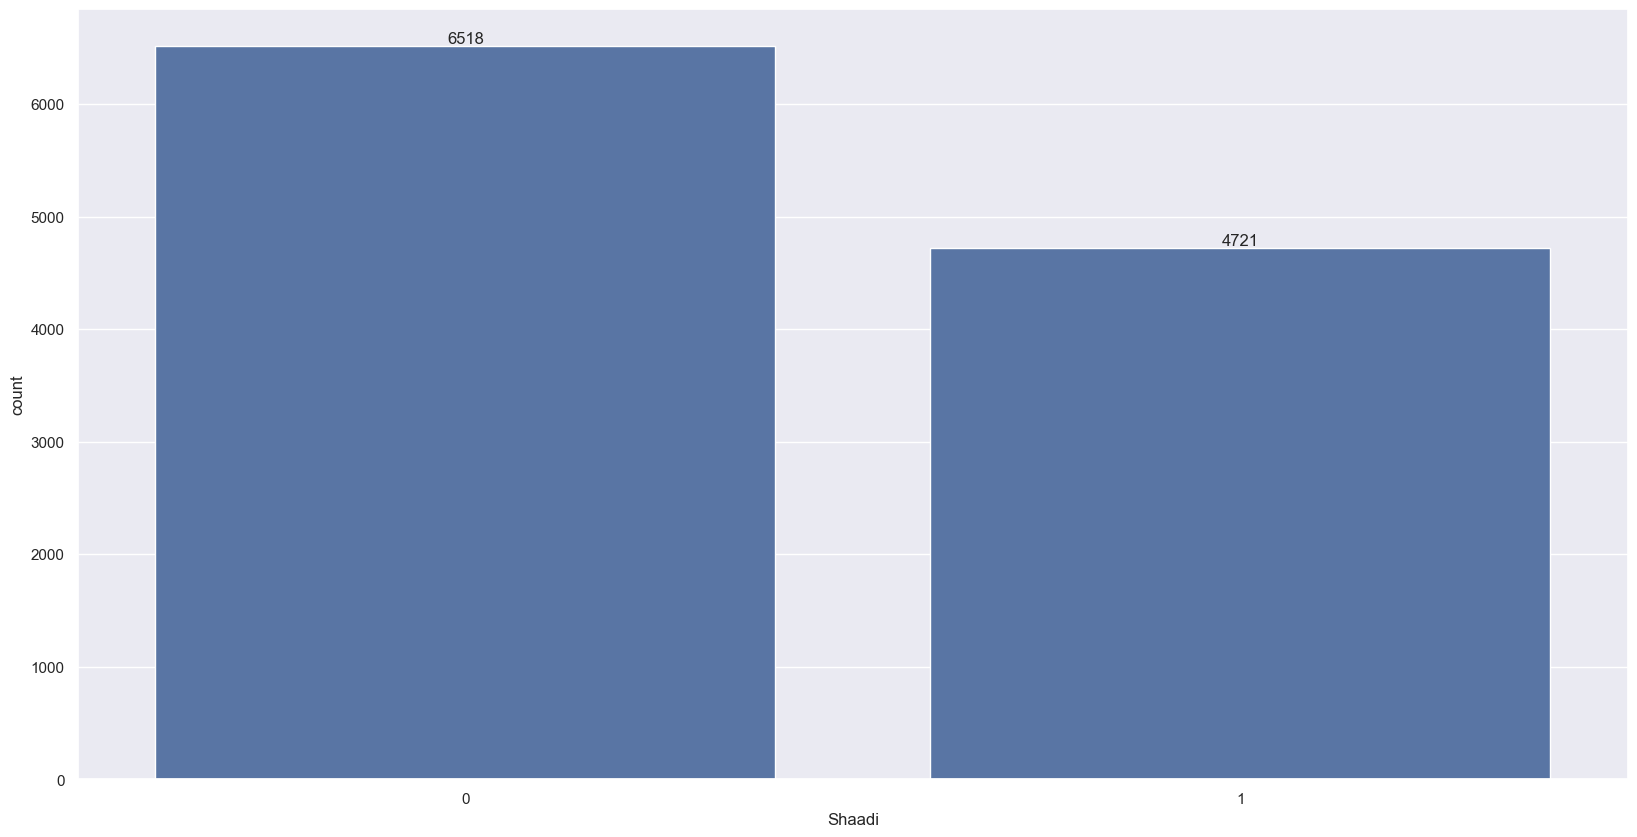

In [75]:
ax = sns.countplot(data = df, x = 'Shaadi')

sns.set(rc={'figure.figsize':(10,10)})
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Shaadi', ylabel='Amount'>

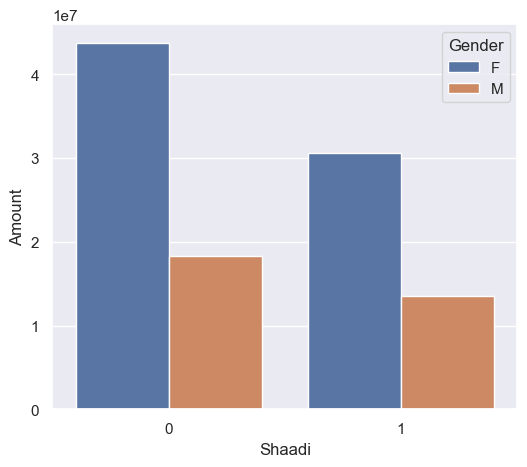

In [86]:
sales_Married = df.groupby(['Shaadi','Gender'], as_index=False )['Amount'].sum().sort_values(by = ['Amount'], ascending = False)
sns.set(rc={'figure.figsize':(6,5)})
sns.barplot(x = 'Shaadi', y = 'Amount', data = sales_Married, hue = 'Gender')